#  Smart Advertising Sales Prediction & Budget Optimizer

Welcome! 

---

## 1. Import Libraries
Let us start by importing all the libraries we'll need for data analysis, visualization, and machine learning.

In [155]:
# Import essential libraries for data science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Set plot style for better visuals
sns.set(style="whitegrid")  # this will make our plots look nicer by adding a grid and improving the overall aesthetics

## 2. Load the Dataset

Let's load the advertising dataset. Make sure the CSV file is in the same folder as this notebook or provide the correct path.

In [156]:
# Load the dataset and fix columns
file_path = "Advertising Budget and Sales.csv"
df = pd.read_csv(file_path, index_col=0)  # Use the first column as index
df.columns = ['TV', 'Radio', 'Newspaper', 'Sales']
print(df.head())

      TV  Radio  Newspaper  Sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9


In [157]:
# Check the structure and types of the data
print("\n--- Dataset Informationg is here ---")
df.info()
print("\n--- First 5 Rows are here ---")
display(df.head())


--- Dataset Informationg is here ---
<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB

--- First 5 Rows are here ---


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 3. Data Preprocessing

Let's clean the data by handling missing values, removing duplicates, and checking for outliers. This ensures our model learns from high-quality data.

In [158]:
# Check for missing values in each column
print("Missing values per column are here -:")
df.isnull().sum()

Missing values per column are here -:


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [159]:
# Drop rows with missing values (if any)
print(f"Rows before the dropping missing values: {len(df)}")

df = df.dropna()
print(f"Rows after dropping missing values: {len(df)}")

if df.duplicated().sum() > 0:
    print("There are still duplicate rows in the dataset.")
else:
    print("No duplicate rows found in the dataset.")

Rows before the dropping missing values: 200
Rows after dropping missing values: 200
No duplicate rows found in the dataset.


In [160]:
# Remove duplicate rows (if any)
print(f"Rows before dropping duplicates: {len(df)}")

df = df.drop_duplicates()
print(f"Rows after dropping duplicates: {len(df)}")

if df.duplicated().sum() > 0:
    print("There are still duplicate rows in the dataset.")
else:
    print("No duplicate rows found in the dataset.")

Rows before dropping duplicates: 200
Rows after dropping duplicates: 200
No duplicate rows found in the dataset.


In [161]:
# Get summary statistics to understand the data distribution
print("\n--- Here is the  Data Description ---")
df.describe()


--- Here is the  Data Description ---


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [162]:
# (No renaming needed here anymore)

## 4. Exploratory Data Analysis (EDA) & Visualization

Let's visualize the relationships between advertising budgets and sales, and check feature correlations.

In [163]:
# (No index dropping needed here anymore)

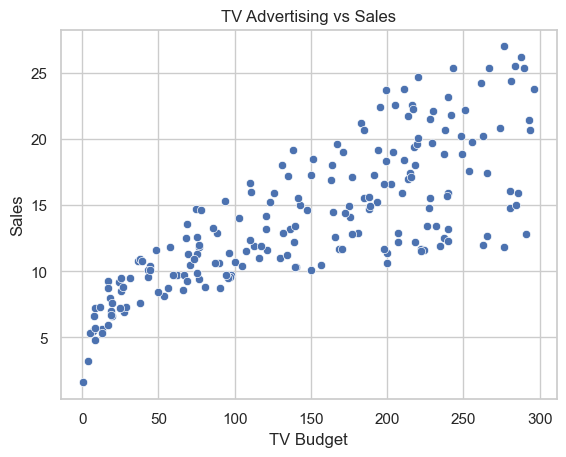

In [164]:
# Visualize TV budget vs Sales
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.show()

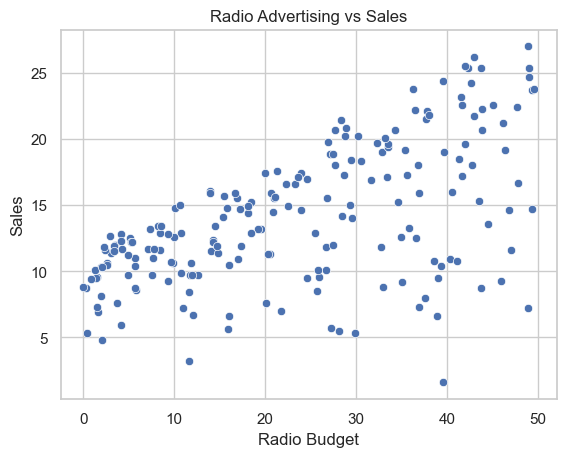

In [165]:
# Visualize Radio budget vs Sales
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Budget")
plt.ylabel("Sales")
plt.show()

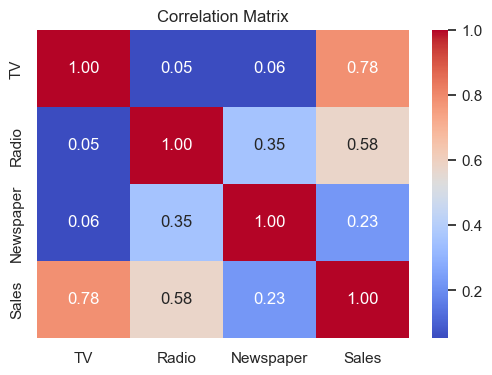

In [166]:
# Show correlation matrix as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [167]:
# Define features and target variable
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [168]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 160, Test samples: 40


In [169]:
# 5. Model Training & Evaluation
# Let's train and evaluate multiple models for comparison.

# Standardize features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# Train Decision Tree
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

# Train Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Evaluate all models
def print_metrics(name, y_true, y_pred):
    print(f"{name} - MAE: {mean_absolute_error(y_true, y_pred):.2f}, R2: {r2_score(y_true, y_pred):.2f}")

print_metrics("Linear Regression", y_test, lr_pred)
print_metrics("Decision Tree", y_test, tree_pred)
print_metrics("Random Forest", y_test, rf_pred)

Linear Regression - MAE: 1.46, R2: 0.90
Decision Tree - MAE: 0.99, R2: 0.93
Random Forest - MAE: 0.62, R2: 0.98


In [170]:
# Example: Predict with a trained model (replace 'model' with your trained model, e.g., lr, tree, or rf)
y_pred = rf.predict(X_test)  # Use rf, lr, or tree as needed

In [171]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 0.6200999999999988
R2 Score: 0.9812843792541843


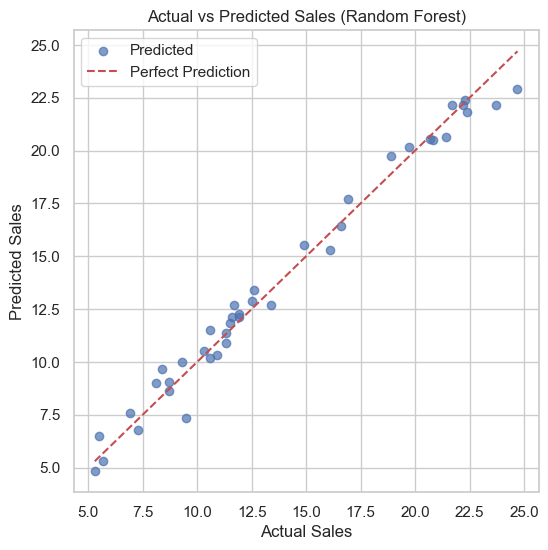

In [172]:
# Visualize Actual vs Predicted for the best model (Random Forest)
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.7, label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.legend()
plt.show()

In [173]:
# 6. Make Predictions with the Best Model
# Example: Predict sales for a new advertising budget
new_data = pd.DataFrame([[150, 25, 10]], columns=['TV', 'Radio', 'Newspaper'])
new_data_scaled = scaler.transform(new_data)
predicted_sales = rf.predict(new_data)
print(f"Predicted Sales for TV=150, Radio=25, Newspaper=10: {predicted_sales[0]:.2f}")

Predicted Sales for TV=150, Radio=25, Newspaper=10: 15.22


In [174]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, tree_pred))

Decision Tree R2: 0.9302123193750712


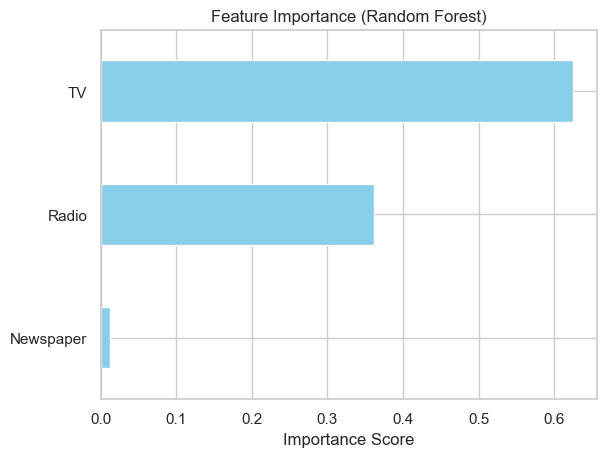

In [175]:
# Visualize feature importance from Random Forest
feat_importances = pd.Series(rf.feature_importances_, index=['TV','Radio','Newspaper'])
feat_importances.sort_values().plot(kind='barh', color='skyblue')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

## Conclusion & Insights

- Random Forest performed best for predicting sales based on advertising budgets.
- TV and Radio budgets have the highest impact on sales, while Newspaper is less important.